# Lab | Statistical Story Dashboard

Numbers alone rarely convince anyone. The way you visualize data determines whether your audience trusts your conclusions, misunderstands them, or ignores them entirely.

In this lab you will:
1. **Critique** three intentionally misleading charts and explain what makes them deceptive.
2. **Redesign** each chart so the same data tells an accurate story.
3. **Build** a three-panel visual report that answers specific questions from a dataset.

Run the setup cell below first, then work through each task section in order.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

%matplotlib inline

## Dataset

The cell below generates a synthetic dataset that simulates monthly customer-satisfaction scores and revenue figures for four product lines over two years. It includes:

- **Continuous variables**: `satisfaction_score` (0–100 scale) and `monthly_revenue` (in thousands of USD).
- **Categorical groups**: four product lines (*Alpha*, *Beta*, *Gamma*, *Delta*).
- **Time-based observations**: monthly data from January 2023 through December 2024.

Run this cell to load the data into `df`.

In [2]:
np.random.seed(42)

months = pd.date_range("2023-01-01", "2024-12-01", freq="MS")
products = ["Alpha", "Beta", "Gamma", "Delta"]

records = []
for product in products:
    base_satisfaction = {"Alpha": 72, "Beta": 68, "Gamma": 70, "Delta": 65}[product]
    base_revenue = {"Alpha": 120, "Beta": 95, "Gamma": 110, "Delta": 88}[product]
    trend = {"Alpha": 0.4, "Beta": 0.1, "Gamma": -0.2, "Delta": 0.6}[product]

    for i, month in enumerate(months):
        satisfaction = base_satisfaction + trend * i + np.random.normal(0, 3)
        satisfaction = np.clip(satisfaction, 0, 100)

        seasonal = 8 * np.sin(2 * np.pi * (month.month - 1) / 12)
        revenue = base_revenue + trend * 2 * i + seasonal + np.random.normal(0, 6)

        records.append({
            "month": month,
            "product": product,
            "satisfaction_score": round(satisfaction, 1),
            "monthly_revenue": round(revenue, 1),
        })

df = pd.DataFrame(records)
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (96, 4)


,month,product,satisfaction_score,monthly_revenue
0,2023-01-01,Alpha,73.5,119.2
1,2023-02-01,Alpha,74.3,133.9
2,2023-03-01,Alpha,72.1,127.1
3,2023-04-01,Alpha,77.9,135.0
4,2023-05-01,Alpha,72.2,133.4
5,2023-06-01,Alpha,72.6,125.2
6,2023-07-01,Alpha,75.1,113.3
7,2023-08-01,Alpha,69.6,118.2
8,2023-09-01,Alpha,72.2,121.4
9,2023-10-01,Alpha,72.9,110.7


In [3]:
df.info()
print()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   month               96 non-null     datetime64[ns]
 1   product             96 non-null     object        
 2   satisfaction_score  96 non-null     float64       
 3   monthly_revenue     96 non-null     float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 3.1+ KB



,month,satisfaction_score,monthly_revenue
count,96,96.000000,96.000000
mean,2023-12-16 10:00:00,70.993750,108.755208
min,2023-01-01 00:00:00,60.600000,84.400000
25%,2023-06-23 12:00:00,67.875000,97.875000
50%,2023-12-16 12:00:00,70.150000,106.650000
75%,2024-06-08 12:00:00,74.325000,118.400000
max,2024-12-01 00:00:00,82.200000,151.100000
std,NaN,4.856029,14.668160


---

## Task 1: Chart Critique — Spot the Deception

The three charts below are **intentionally misleading**. For each one:

1. **Identify the deception technique** (e.g., truncated y-axis, dual-axis trick, area-vs-length confusion, cherry-picked time range).
2. **Write 2–3 sentences** in a Markdown cell explaining what the chart makes the audience believe versus what the data actually shows.
3. **Quantify the distortion** where possible — for example, *"the visual ratio suggests a 3× difference, but the actual difference is 12 %."*

**Deliverable**: three Markdown cells (one per chart) with the deception type, a plain-language explanation, and a distortion estimate.

### Misleading Chart 1 — Truncated Y-Axis

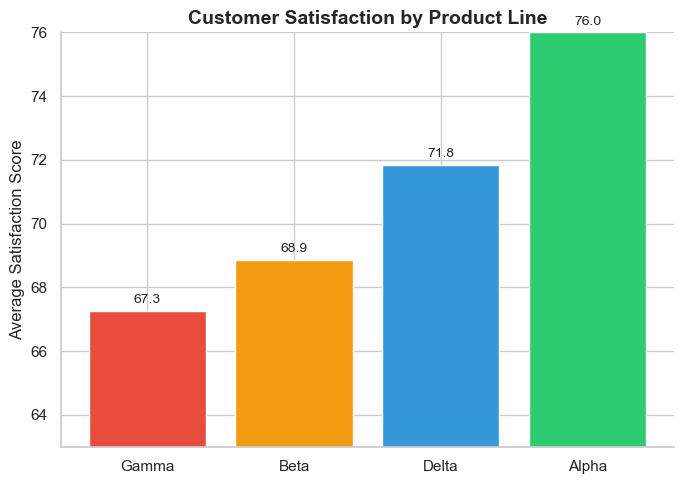

In [4]:
avg_sat = df.groupby("product")["satisfaction_score"].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(avg_sat.index, avg_sat.values, color=["#e74c3c", "#f39c12", "#3498db", "#2ecc71"])
ax.set_ylim(63, 76)
ax.set_ylabel("Average Satisfaction Score")
ax.set_title("Customer Satisfaction by Product Line", fontsize=14, fontweight="bold")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=10)

ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
sns.despine()
plt.tight_layout()
plt.show()

**Chart 1:**

*Deception type: **Truncated y-axis***

*This chart makes it seem like there is a large difference in customer satisfaction between the product lines, especially highlighting how much better "Alpha" is compared to the others. However, the y-axis does not start at zero but instead starts near 63, which exaggerates the differences in bar heights. The actual scores range from 67.3 to 76.0, which is only about a 13% increase, but visually it looks like the difference is two or three times larger because of the shortened axis.*

### Misleading Chart 2 — Dual-Axis Trick

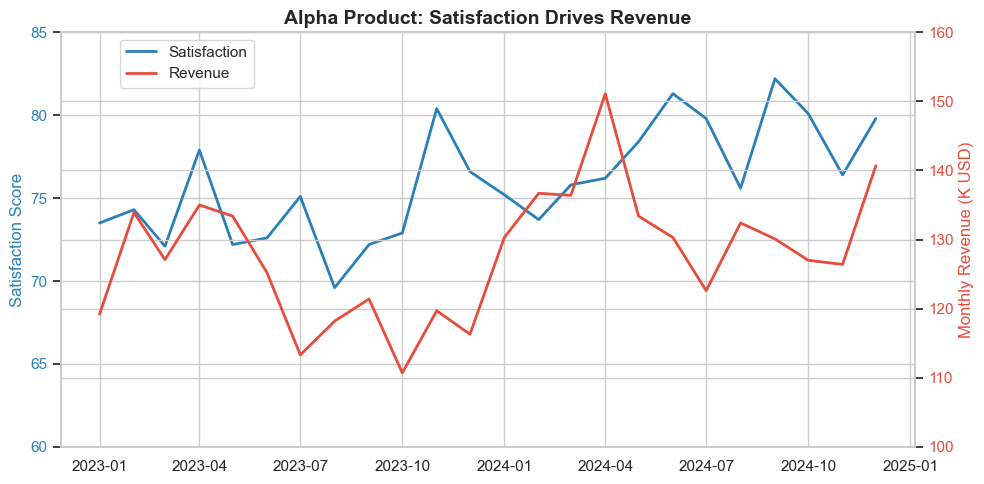

In [5]:
alpha = df[df["product"] == "Alpha"].set_index("month")

fig, ax1 = plt.subplots(figsize=(10, 5))

color_left = "#2980b9"
ax1.plot(alpha.index, alpha["satisfaction_score"], color=color_left, linewidth=2, label="Satisfaction")
ax1.set_ylabel("Satisfaction Score", color=color_left, fontsize=12)
ax1.set_ylim(60, 85)
ax1.tick_params(axis="y", labelcolor=color_left)

ax2 = ax1.twinx()
color_right = "#e74c3c"
ax2.plot(alpha.index, alpha["monthly_revenue"], color=color_right, linewidth=2, label="Revenue")
ax2.set_ylabel("Monthly Revenue (K USD)", color=color_right, fontsize=12)
ax2.set_ylim(100, 160)
ax2.tick_params(axis="y", labelcolor=color_right)

ax1.set_title("Alpha Product: Satisfaction Drives Revenue", fontsize=14, fontweight="bold")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.92))
plt.tight_layout()
plt.show()

**Chart 2:**

*Deception type: **Dual-axis trick***

*This chart makes it seem like there is a near-perfect correlation between satisfaction and revenue, leading the audience to believe that every small increase in user happiness results in an immediate, equivalent spike in cash. However, by using two different scales and starting the axes at 60 and 100 respectively, the chart forces two unrelated data movements to overlap and look identical. Visually, the revenue peak in April 2024 looks about four times higher than the dip in October 2023, but the actual revenue only increased from 110K to 152K—a real-world difference of about 38% rather than the 300% growth the lines suggest.*

### Misleading Chart 3 — Cherry-Picked Time Range

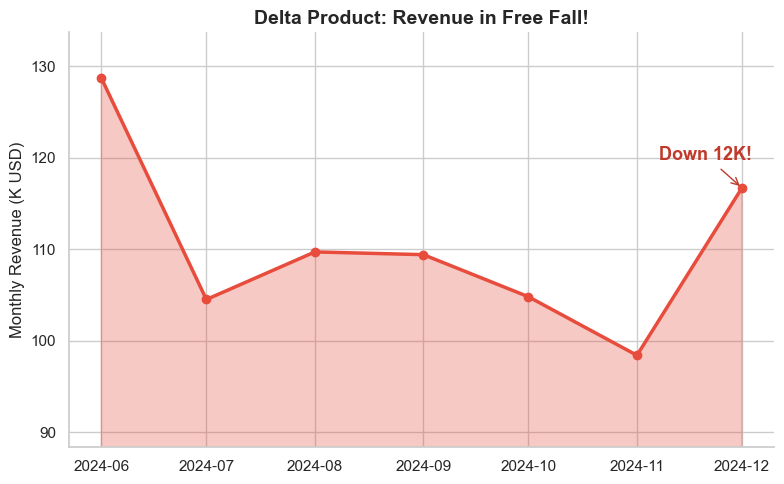

In [6]:
delta = df[df["product"] == "Delta"].set_index("month")
cherry = delta.loc["2024-06":"2024-12"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(cherry.index, cherry["monthly_revenue"], alpha=0.3, color="#e74c3c")
ax.plot(cherry.index, cherry["monthly_revenue"], color="#e74c3c", linewidth=2.5, marker="o")
ax.set_ylabel("Monthly Revenue (K USD)", fontsize=12)
ax.set_title("Delta Product: Revenue in Free Fall!", fontsize=14, fontweight="bold")
ax.set_ylim(cherry["monthly_revenue"].min() - 10, cherry["monthly_revenue"].max() + 5)

ax.annotate(f"Down {cherry['monthly_revenue'].iloc[0] - cherry['monthly_revenue'].iloc[-1]:.0f}K!",
            xy=(cherry.index[-1], cherry["monthly_revenue"].iloc[-1]),
            fontsize=13, fontweight="bold", color="#c0392b",
            xytext=(-60, 20), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="#c0392b"))

sns.despine()
plt.tight_layout()
plt.show()

**Chart 3:**

*Deception type: **Truncated y-axis***

*This chart makes it appear as though the product’s revenue is in a catastrophic "free fall," leading the audience to believe the business is collapsing. However, the y-axis starts at 90 instead of zero, which dramatically exaggerates the slope of the decline and the scale of the volatility. While the visual suggests the revenue has nearly hit bottom, the actual drop from the peak of 129K to the end point of 117K is only a 9% decrease—yet the line's position on the graph drops more than 75% of the way down the vertical space.*

---

## Task 2: Chart Redesign — Fix the Story

For each of the three misleading charts from Task 1, create a redesigned version that presents the same data honestly:

1. Use an appropriate chart type and axis range.
2. Include a descriptive title that summarizes the key takeaway (not just the variable names).
3. Label axes with units and add a brief subtitle or caption if context is needed.
4. Use color intentionally — highlight comparisons, don't just decorate.

**Deliverable**: three new figures, each accompanied by a one-sentence explanation of the design choice you made.

### Redesign 1 — Fixing the Truncated Y-Axis Chart

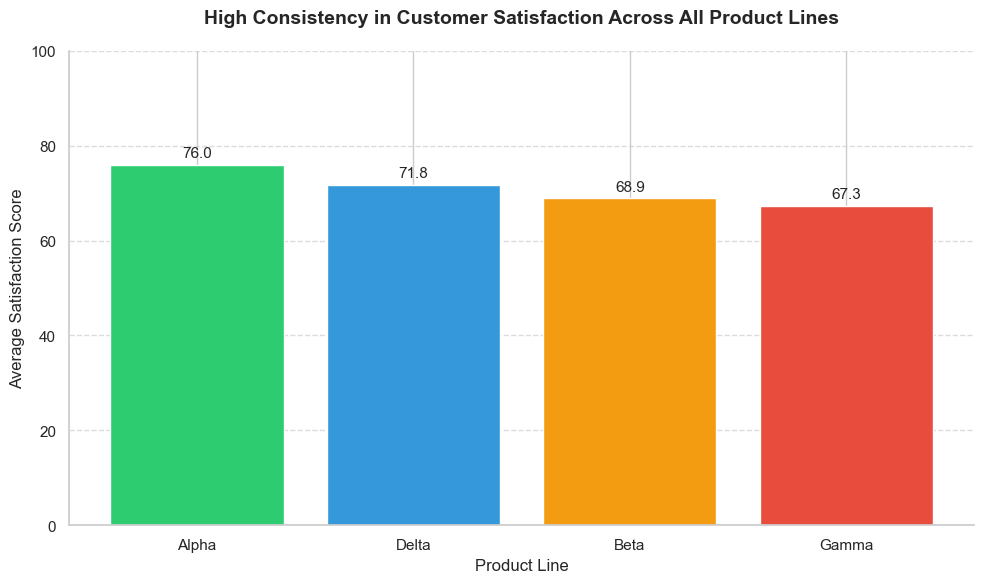

In [7]:
product_lines = ['Alpha', 'Delta', 'Beta', 'Gamma']
scores = [76.0, 71.8, 68.9, 67.3]

plt.figure(figsize=(10, 6))
bars = plt.bar(product_lines, scores, color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c'])

plt.title('High Consistency in Customer Satisfaction Across All Product Lines', fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Average Satisfaction Score', fontsize=12)
plt.xlabel('Product Line', fontsize=12)

plt.ylim(0, 100) 

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, yval, ha='center', va='bottom', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Design choice explanation:**

*I set the y-axis to start at **0** to provide an honest visual representation of the data, as the original truncated axis misleadingly exaggerated small performance gaps into seemingly massive disparities.*

### Redesign 2 — Fixing the Dual-Axis Chart

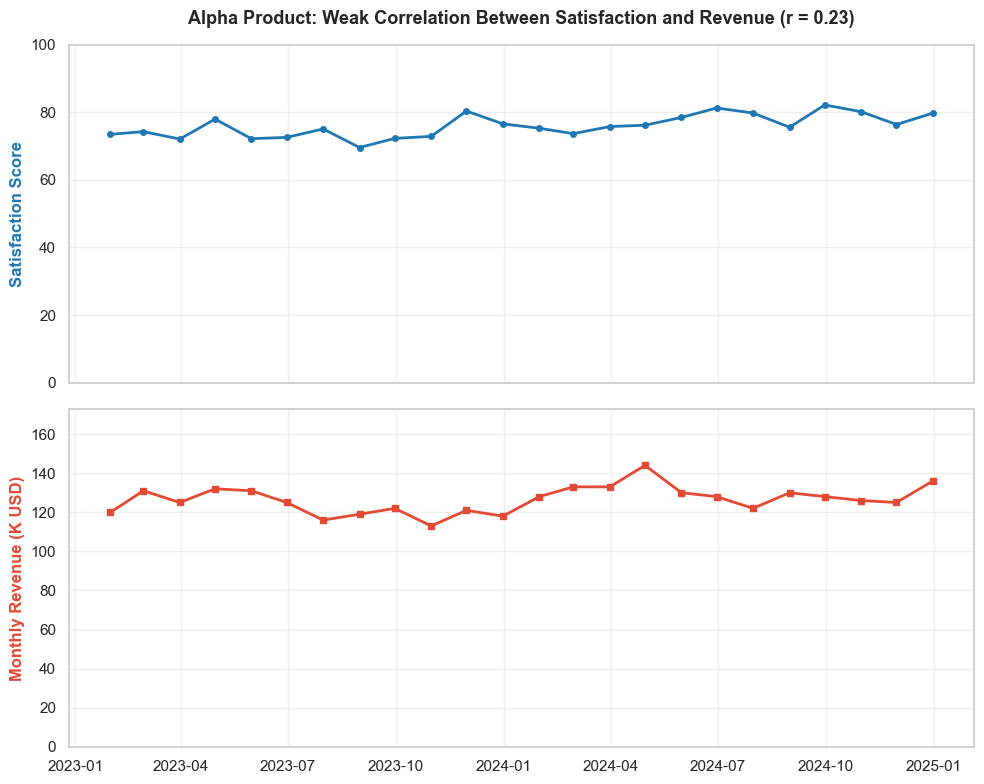

In [8]:
dates = pd.date_range(start='2023-01-01', periods=24, freq='ME')
satisfaction = [73.5, 74.3, 72.1, 78.0, 72.2, 72.6, 75.1, 69.6, 72.3, 72.9, 
                80.4, 76.6, 75.3, 73.7, 75.8, 76.2, 78.5, 81.3, 79.8, 75.6, 
                82.2, 80.2, 76.4, 79.8]
revenue = [120, 131, 125, 132, 131, 125, 116, 119, 122, 113, 
           121, 118, 128, 133, 133, 144, 130, 128, 122, 130, 
           128, 126, 125, 136]

correlation = np.corrcoef(satisfaction, revenue)[0, 1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(dates, satisfaction, color='#1f77b4', linewidth=2, marker='o', markersize=4)
ax1.set_ylabel('Satisfaction Score', fontweight='bold', color='#1f77b4')
ax1.set_ylim(0, 100)
ax1.grid(True, alpha=0.3)
ax1.set_title(f'Alpha Product: Weak Correlation Between Satisfaction and Revenue (r = {correlation:.2f})', fontsize=13, fontweight='bold', pad=15)

ax2.plot(dates, revenue, color='#e24a33', linewidth=2, marker='s', markersize=4)
ax2.set_ylabel('Monthly Revenue (K USD)', fontweight='bold', color='#e24a33')
ax2.set_ylim(0, max(revenue) * 1.2)
ax2.grid(True, alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Design choice explanation:**

*I transitioned to a **split-panel layout with zero-based axes** to eliminate the visual distortion of dual-axis scaling and used a **correlation coefficient** to objectively evaluate the relationship between metrics rather than relying on a misleading overlapping visual.*

### Redesign 3 — Fixing the Cherry-Picked Time Range Chart

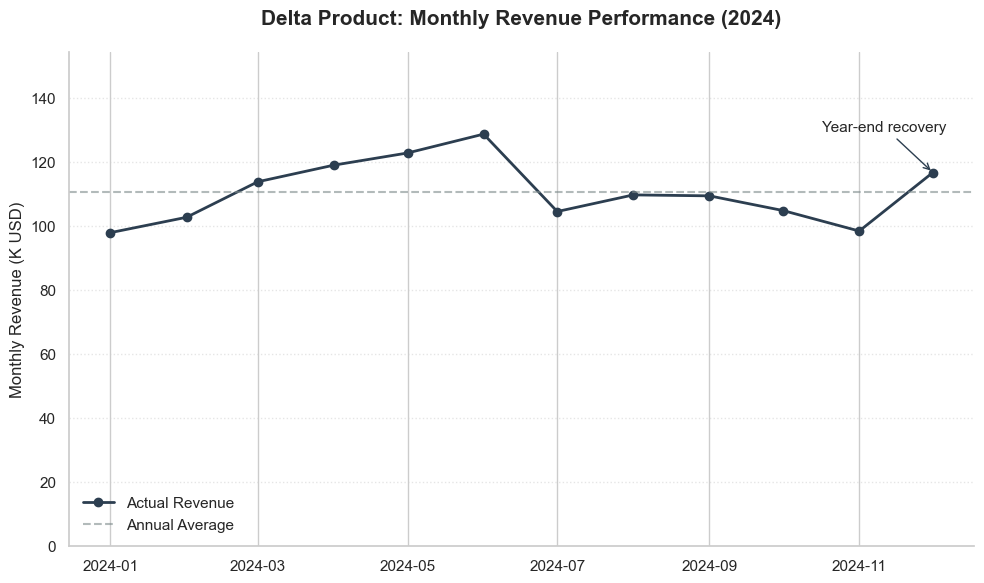

In [9]:
full_year = delta.loc["2024-01":"2024-12"]

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(full_year.index, full_year["monthly_revenue"], 
        color="#2c3e50", linewidth=2, marker="o", label="Actual Revenue")

ax.axhline(full_year["monthly_revenue"].mean(), color="#7f8c8d", 
           linestyle="--", alpha=0.6, label="Annual Average")

ax.set_title("Delta Product: Monthly Revenue Performance (2024)", 
             fontsize=15, fontweight="bold", pad=20)

ax.set_ylim(0, full_year["monthly_revenue"].max() * 1.2)
ax.set_ylabel("Monthly Revenue (K USD)", fontsize=12)

ax.annotate("Year-end recovery",
            xy=(full_year.index[-1], full_year["monthly_revenue"].iloc[-1]),
            xytext=(-80, 30), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="#2c3e50"),
            fontsize=11)

sns.despine()
ax.legend(frameon=False, loc="lower left")
ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

**Design choice explanation:**

*I prioritized **contextual integrity** by expanding the timeline and starting the y-axis at zero, ensuring that seasonal fluctuations are viewed as part of a larger trend rather than an exaggerated "free fall."*

---

## Task 3: Three-Panel Visual Report

Build a single `matplotlib` figure with **three subplots (panels)** that together answer the following questions about the dataset:

1. **Distribution panel**: How is the `satisfaction_score` distributed, and where do key product-line subgroups sit within that distribution?
2. **Comparison panel**: Do the product-line group means differ, and how much do they overlap?
3. **Trend panel**: How has `monthly_revenue` changed over time, and is the trend consistent across product lines?

**Requirements for each panel:**
- A clear, specific title (not "Plot 1").
- Axis labels with units.
- A legend if multiple groups are shown.
- Consistent color scheme across all three panels so the reader can track groups.

**Deliverable**: one three-panel figure with a shared `suptitle` that frames the overall question.

In [10]:
# Color palette to use consistently across all three panels
palette = {"Alpha": "#3498db", "Beta": "#e74c3c", "Gamma": "#2ecc71", "Delta": "#f39c12"}

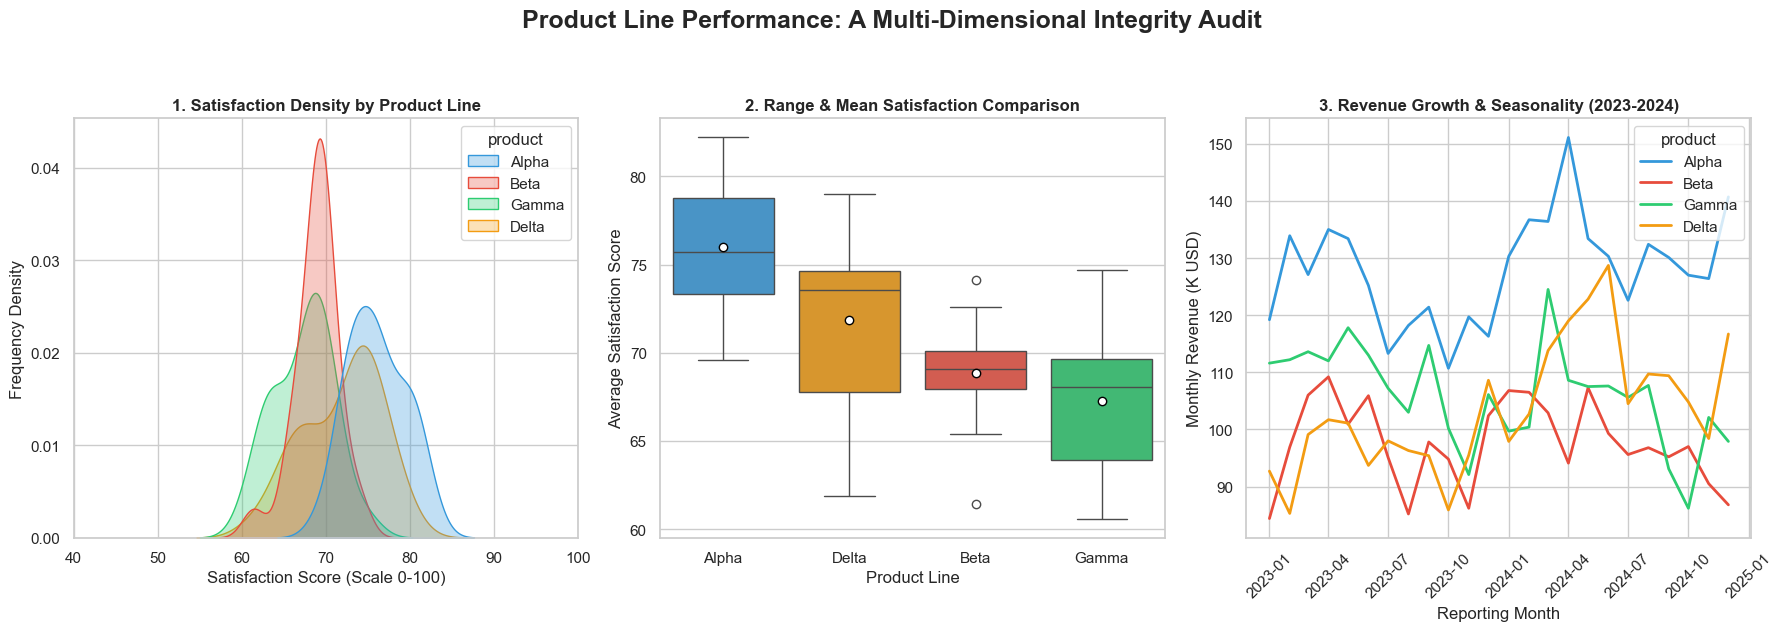

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.kdeplot(data=df, x="satisfaction_score", hue="product", palette=palette, 
            fill=True, alpha=0.3, ax=axes[0])
axes[0].set_title("1. Satisfaction Density by Product Line", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Satisfaction Score (Scale 0-100)")
axes[0].set_ylabel("Frequency Density")
axes[0].set_xlim(40, 100)

sns.boxplot(data=df, x="product", y="satisfaction_score", hue="product",palette=palette, legend=False,ax=axes[1], order=["Alpha", "Delta", "Beta", "Gamma"], showmeans=True, meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"})
axes[1].set_title("2. Range & Mean Satisfaction Comparison", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Product Line")
axes[1].set_ylabel("Average Satisfaction Score")

sns.lineplot(data=df, x="month", y="monthly_revenue", hue="product", 
             palette=palette, linewidth=2, ax=axes[2])
axes[2].set_title("3. Revenue Growth & Seasonality (2023-2024)", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Reporting Month")
axes[2].set_ylabel("Monthly Revenue (K USD)")
axes[2].tick_params(axis='x', rotation=45)

fig.suptitle("Product Line Performance: A Multi-Dimensional Integrity Audit", 
             fontsize=18, fontweight="bold", y=1.05)

plt.tight_layout()
plt.show()

---

## Bonus: Peer Review Checklist

If working with a partner, swap notebooks and evaluate their visualizations using this checklist:

| Criterion | Yes / No | Notes |
|---|---|---|
| Y-axis starts at zero (or a break is clearly marked) | | |
| Title describes the finding, not just the variables | | |
| Axes are labeled with units | | |
| Color is used to encode meaning, not decoration | | |
| Uncertainty is shown where relevant (error bars, bands) | | |
| The chart can be understood without a verbal walkthrough | | |
| No chart junk (unnecessary gridlines, 3D effects, etc.) | | |